In [1]:
import pandas as pd
import numpy as np
import glob
import networkx as nx
import os
import matplotlib.pyplot as plt

In [2]:
def build_graphs(df):
    df = df[["timestamp", "pair", "close"]]
    df_pivot = df.pivot(index="timestamp", columns="pair", values="close")
    df_log = -np.log(df_pivot)

    graphs = {}
    for timestamp, row in df_log.iterrows():
        G = nx.DiGraph()
        for pair, weight in row.items():
            if pd.notna(weight):
                from_currency = pair[:3]
                to_currency = pair[3:]
                G.add_edge(from_currency, to_currency, weight=weight)
        graphs[timestamp] = G
    return graphs

/tmp/ipykernel_230662/561946597.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


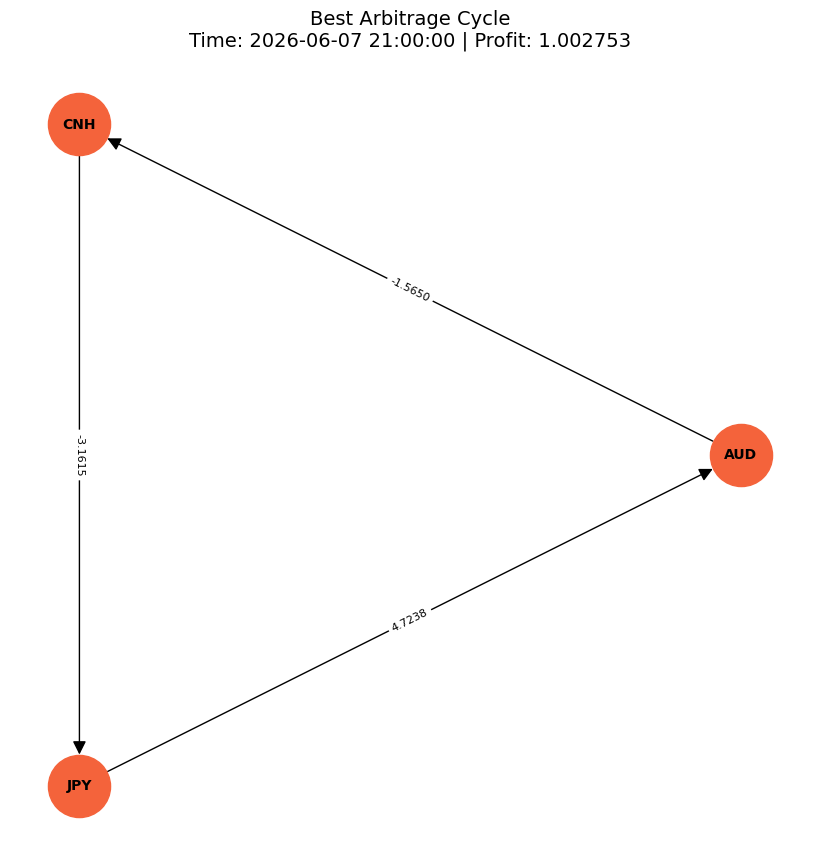

Best arbitrage cycle on 2026-06-07 at 2026-06-07 21:00:00
Profit multiplier: 1.002753
Cycle: AUD → CNH → JPY → AUD


In [3]:
folder = "Arbitrage_Cycles"
best_cycle_info = None

for file in sorted(glob.glob(os.path.join(folder, "arbitrage_*.csv"))):
    df = pd.read_csv(file, parse_dates=["timestamp"])
    if df.empty:
        continue

    row = df.loc[df["profit_multiplier"].idxmax()]
    if best_cycle_info is None or row["profit_multiplier"] > best_cycle_info["profit_multiplier"]:
        best_cycle_info = row

cycle_str = best_cycle_info["cycle"]
profit = best_cycle_info["profit_multiplier"]
timestamp = pd.to_datetime(best_cycle_info["timestamp"])
date_str = str(best_cycle_info["date"])
cycle_nodes = cycle_str.split(" → ")
cycle_edges = list(zip(cycle_nodes, cycle_nodes[1:]))

data_file = f"./Data/forex_intraday_{date_str}.csv"
if not os.path.exists(data_file):
    raise FileNotFoundError(f"Data file for {date_str} not found: {data_file}")

df_day = pd.read_csv(data_file, parse_dates=["timestamp"])
graphs_for_day = build_graphs(df_day)

if timestamp not in graphs_for_day:
    raise KeyError(f"Timestamp {timestamp} not found in graphs for {date_str}.")

G_base = graphs_for_day[timestamp]

G_cycle = nx.DiGraph()
for u, v in cycle_edges:
    if G_base.has_edge(u, v):
        weight = G_base[u][v]["weight"]
        G_cycle.add_edge(u, v, weight=weight)

pos = nx.circular_layout(G_cycle)
edge_labels = nx.get_edge_attributes(G_cycle, "weight")
formatted_labels = {edge: f"{w:.4f}" for edge, w in edge_labels.items()}

plt.figure(figsize=(8, 8))
nx.draw(G_cycle, pos, with_labels=True, node_size=2000, node_color="#F4633B",
        font_size=10, font_weight='bold', arrows=True, arrowsize=20)
nx.draw_networkx_edge_labels(G_cycle, pos, edge_labels=formatted_labels, font_size=8)

plt.title(f"Best Arbitrage Cycle\nTime: {timestamp} | Profit: {profit:.6f}", size=14)
plt.axis('off')
plt.tight_layout()
plt.savefig(os.path.join("Results", "best_overall_arbitrage_cycle.png"), dpi=300, bbox_inches='tight')
plt.show()

print(f"Best arbitrage cycle on {date_str} at {timestamp}")
print(f"Profit multiplier: {profit:.6f}")
print(f"Cycle: {cycle_str}")

/tmp/ipykernel_230662/2951689449.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


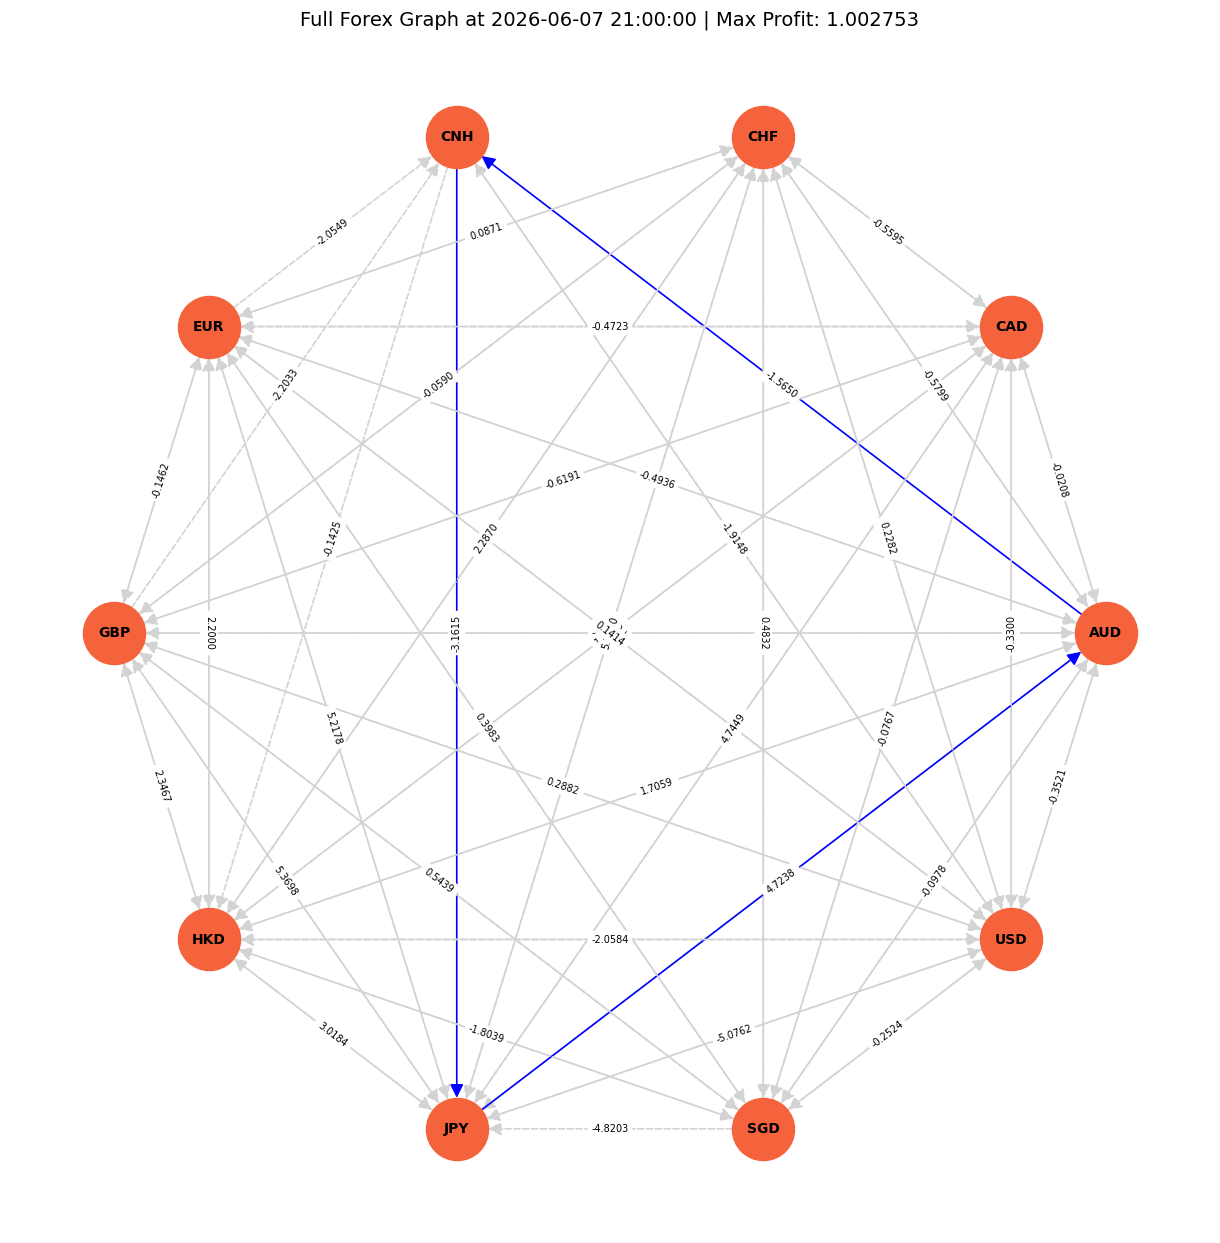

In [4]:
G_full = graphs_for_day[timestamp]

cycle_edge_set = set(cycle_edges)
edge_colors = []
for u, v in G_full.edges():
    if (u, v) in cycle_edge_set:
        edge_colors.append("blue")
    else:
        edge_colors.append("lightgray")

edge_styles = []
edge_widths = []
for u, v in G_full.edges():
    if (u, v) in cycle_edge_set:
        edge_styles.append("solid")
        edge_widths.append(4.5)
    else:
        edge_styles.append("dashed")
        edge_widths.append(0.6)

pos = nx.circular_layout(G_full)
edge_labels = nx.get_edge_attributes(G_full, "weight")
formatted_labels = {edge: f"{w:.4f}" for edge, w in edge_labels.items()}

# Plot
plt.figure(figsize=(12, 12))
nx.draw(G_full, pos,
        with_labels=True,
        node_size=2000,
        node_color="#F4633B",
        font_size=10,
        font_weight='bold',
        edge_color=edge_colors,
        style = edge_styles,
        width=1.2,
        arrows=True,
        arrowsize=20)

nx.draw_networkx_edge_labels(G_full, pos, edge_labels=formatted_labels, font_size=7)

plt.title(f"Full Forex Graph at {timestamp} | Max Profit: {profit:.6f}", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.savefig(os.path.join("Results", "full_forex_graph_best_timestamp.png"), dpi=300)
plt.show()

In [5]:
df = pd.read_csv("Arbitrage_Cycles/arbitrage_2026-06-01.csv")
print(df.head())
print(df.columns)

                   cycle   log_sum  profit_multiplier            timestamp  \
0        JPY → HKD → JPY -0.000009           1.000009  2026-06-01 00:05:00   
1        HKD → JPY → HKD -0.000031           1.000031  2026-06-01 00:08:00   
2        JPY → HKD → JPY -0.000040           1.000040  2026-06-01 00:10:00   
3        CAD → AUD → CAD -0.000031           1.000031  2026-06-01 00:11:00   
4  JPY → EUR → USD → JPY -0.000029           1.000029  2026-06-01 00:25:00   

         date  
0  2026-06-01  
1  2026-06-01  
2  2026-06-01  
3  2026-06-01  
4  2026-06-01  
Index(['cycle', 'log_sum', 'profit_multiplier', 'timestamp', 'date'], dtype='object')


In [6]:
import pandas as pd
import glob
import os

summary = []

files = sorted(glob.glob("Arbitrage_Cycles/arbitrage_*.csv"))

for file in files:
    df = pd.read_csv(file)

    date = os.path.basename(file).replace("arbitrage_", "").replace(".csv", "")

    if df.empty:
        summary.append({
            "date": date,
            "num_cycles": 0,
            "avg_cycle_profit": 0,
            "max_cycle_profit": 0
        })
        continue

    summary.append({
        "date": date,
        "num_cycles": len(df),
        "avg_cycle_profit": df["profit_multiplier"].mean(),
        "max_cycle_profit": df["profit_multiplier"].max()
    })

summary_df = pd.DataFrame(summary)

summary_df.to_csv("daily_arbitrage_summary.csv", index=False)

print(summary_df)

print("\n" + "="*50)
print("OVERALL SUMMARY")
print("="*50)

print(f"Trading Days            : {len(summary_df)}")
print(f"Total Arbitrage Cycles  : {summary_df['num_cycles'].sum():,}")
print(f"Average Cycles / Day    : {summary_df['num_cycles'].mean():.2f}")
print(f"Average Cycle Profit    : {summary_df['avg_cycle_profit'].mean():.9f}")
print(f"Maximum Cycle Profit    : {summary_df['max_cycle_profit'].max():.9f}")

best = summary_df.loc[summary_df["num_cycles"].idxmax()]

print("\nBest Trading Day")
print(f"Date                    : {best['date']}")
print(f"Arbitrage Cycles        : {best['num_cycles']:,}")

print("="*50)

         date  num_cycles  avg_cycle_profit  max_cycle_profit
0  2026-06-01         422          1.000042          1.000446
1  2026-06-02         386          1.000037          1.000503
2  2026-06-03         467          1.000044          1.001570
3  2026-06-04         991          1.000051          1.000744
4  2026-06-05         440          1.000036          1.000839
5  2026-06-07          16          1.000191          1.002753

OVERALL SUMMARY
Trading Days            : 6
Total Arbitrage Cycles  : 2,722
Average Cycles / Day    : 453.67
Average Cycle Profit    : 1.000066652
Maximum Cycle Profit    : 1.002753262

Best Trading Day
Date                    : 2026-06-04
Arbitrage Cycles        : 991
